<a href="https://colab.research.google.com/github/Ashishpathak78/DL_practice/blob/main/DL_Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.26MB/s]


Epoch [1/2], Loss: 0.0311
Epoch [2/2], Loss: 0.1439


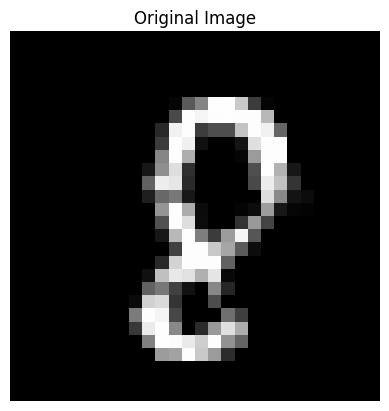

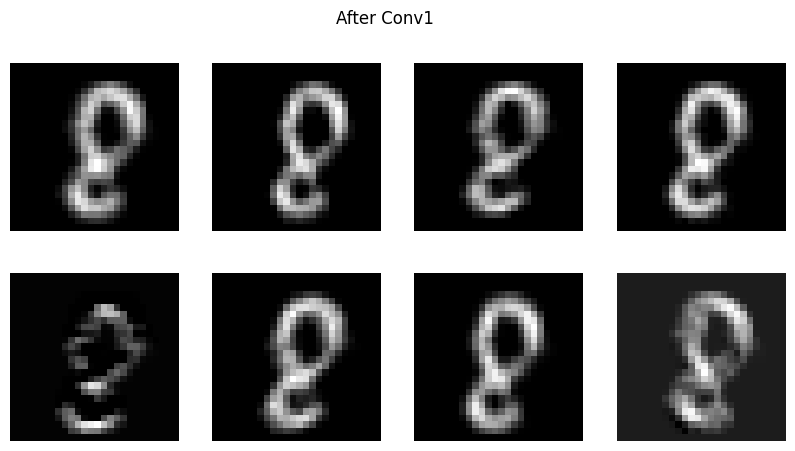

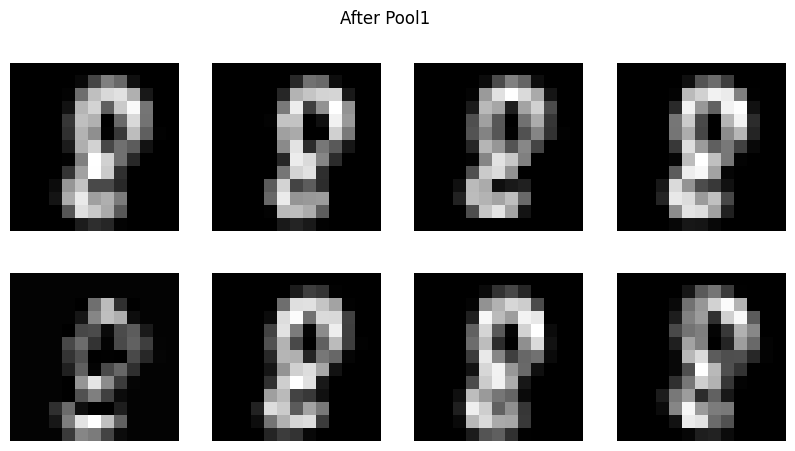

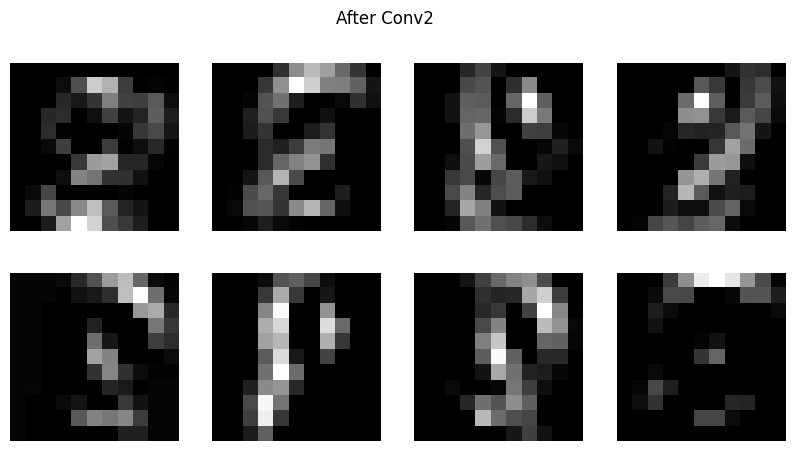

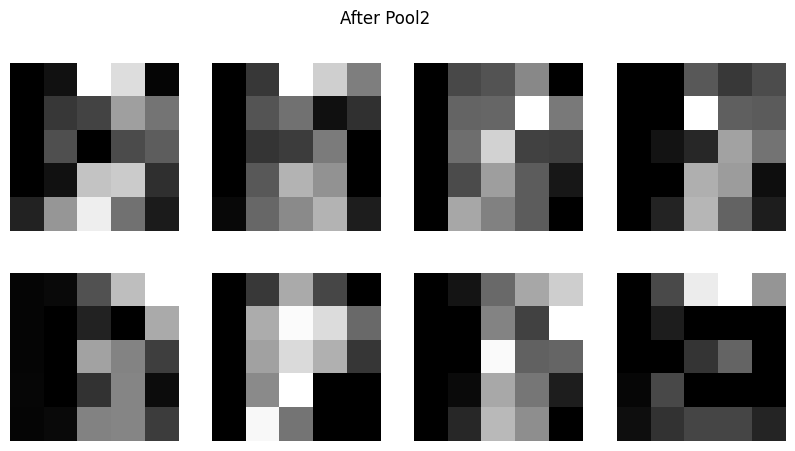

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, shuffle=True)

# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)   # (28x28 -> 26x26)
        self.pool = nn.MaxPool2d(2, 2)                # (26x26 -> 13x13)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3)  # (13x13 -> 11x11)
        self.fc1 = nn.Linear(16*5*5, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        conv1_out = x

        x = self.pool(x)
        pool1_out = x

        x = self.conv2(x)
        x = torch.relu(x)
        conv2_out = x

        x = self.pool(x)
        pool2_out = x

        x = x.view(-1, 16*5*5)
        x = self.fc1(x)

        return x, conv1_out, pool1_out, conv2_out, pool2_out

model = CNN().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training (quick)
for epoch in range(2):  # keep small for demo
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs, _, _, _, _ = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/2], Loss: {loss.item():.4f}")

# Get one test image
data_iter = iter(test_loader)
image, label = next(data_iter)
image = image.to(device)

# Forward pass
output, conv1, pool1, conv2, pool2 = model(image)

# Move to CPU for plotting
image = image.cpu()
conv1 = conv1.detach().cpu()
pool1 = pool1.detach().cpu()
conv2 = conv2.detach().cpu()
pool2 = pool2.detach().cpu()

# Function to visualize feature maps
def plot_feature_maps(feature_maps, title):
    num_maps = feature_maps.shape[1]
    plt.figure(figsize=(10, 5))
    for i in range(min(num_maps, 8)):  # show first 8 maps
        plt.subplot(2, 4, i+1)
        plt.imshow(feature_maps[0, i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Show results
plt.imshow(image[0][0], cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

plot_feature_maps(conv1, "After Conv1")
plot_feature_maps(pool1, "After Pool1")
plot_feature_maps(conv2, "After Conv2")
plot_feature_maps(pool2, "After Pool2")